In [1]:
# Persiapan eksperimen Poly-1 Loss

from pathlib import Path
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights


# Konfigurasi yang disamakan dengan baseline BCE
SEED = 42
BATCH_SIZE = 16
NUM_WORKERS = 2
IMAGE_SIZE = 224
POLY_EPSILON = 1.0

LABELS = ["N", "D", "G", "C", "A", "H", "M", "O"]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# Menetapkan seed agar eksperimen dapat diulang
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# Lokasi dataset Kaggle
DATASET_DIR = Path(
    "/kaggle/input/datasets/kevinardhana/"
    "odir-5k-patient-level-multi-label-fundus-dataset"
)

IMAGE_DIR = (
    DATASET_DIR
    / "Training Images"
    / "Training Images"
)

TRAIN_CSV = DATASET_DIR / "train.csv"
VALID_CSV = DATASET_DIR / "validation.csv"
TEST_CSV = DATASET_DIR / "test.csv"

POLY_OUTPUT_DIR = Path(
    "/kaggle/working/polyloss"
)
POLY_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Memuat pembagian data
poly_train_df = pd.read_csv(TRAIN_CSV)
poly_valid_df = pd.read_csv(VALID_CSV)
poly_test_df = pd.read_csv(TEST_CSV)


# Memeriksa ukuran dan pemisahan pasien
assert len(poly_train_df) == 2450
assert len(poly_valid_df) == 525
assert len(poly_test_df) == 525

assert set(poly_train_df["patient_id"]).isdisjoint(
    poly_valid_df["patient_id"]
)

assert set(poly_train_df["patient_id"]).isdisjoint(
    poly_test_df["patient_id"]
)

assert set(poly_valid_df["patient_id"]).isdisjoint(
    poly_test_df["patient_id"]
)


# Ringkasan distribusi label hanya dari data training
positive_counts = poly_train_df[LABELS].sum()
negative_counts = len(poly_train_df) - positive_counts

class_distribution_table = pd.DataFrame({
    "label": LABELS,
    "positif_train": positive_counts.values.astype(int),
    "negatif_train": negative_counts.values.astype(int)
})


# Transformasi citra
poly_train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

poly_eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Dataset pasangan mata kiri dan kanan
class PolyFundusPairDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        left_path = self.image_dir / row["left_image"]
        right_path = self.image_dir / row["right_image"]

        left_image = Image.open(left_path).convert("RGB")
        right_image = Image.open(right_path).convert("RGB")

        left_image = self.transform(left_image)
        right_image = self.transform(right_image)

        labels = torch.tensor(
            row[LABELS].values.astype(np.float32),
            dtype=torch.float32
        )

        return {
            "left_image": left_image,
            "right_image": right_image,
            "labels": labels,
            "patient_id": int(row["patient_id"])
        }


poly_train_dataset = PolyFundusPairDataset(
    poly_train_df,
    IMAGE_DIR,
    poly_train_transform
)

poly_valid_dataset = PolyFundusPairDataset(
    poly_valid_df,
    IMAGE_DIR,
    poly_eval_transform
)

poly_test_dataset = PolyFundusPairDataset(
    poly_test_df,
    IMAGE_DIR,
    poly_eval_transform
)


poly_train_loader = DataLoader(
    poly_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda"
)

poly_valid_loader = DataLoader(
    poly_valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda"
)

poly_test_loader = DataLoader(
    poly_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda"
)


# Arsitektur yang sama dengan baseline BCE
class PolySharedResNet50(nn.Module):
    def __init__(self, num_labels=8, dropout=0.30):
        super().__init__()

        self.backbone = resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V2
        )

        feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feature_dim * 2, num_labels)
        )

    def forward(self, left_image, right_image):
        left_features = self.backbone(left_image)
        right_features = self.backbone(right_image)

        combined_features = torch.cat(
            [left_features, right_features],
            dim=1
        )

        return self.classifier(combined_features)


poly_model = PolySharedResNet50(
    num_labels=len(LABELS)
).to(DEVICE)


# Perbedaan utama dari BCE standar
class Poly1Loss(nn.Module):
    def __init__(self, epsilon=1.0):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )
        probabilities = torch.sigmoid(logits)
        p_t = (
            probabilities * targets
            + (1.0 - probabilities) * (1.0 - targets)
        )
        poly_term = self.epsilon * (1.0 - p_t)
        return (bce_loss + poly_term).mean()


poly_criterion = Poly1Loss(
    epsilon=POLY_EPSILON
)


# Pemeriksaan satu batch
poly_batch = next(iter(poly_train_loader))

left_batch = poly_batch["left_image"].to(DEVICE)
right_batch = poly_batch["right_image"].to(DEVICE)
label_batch = poly_batch["labels"].to(DEVICE)

with torch.no_grad():
    poly_logits = poly_model(
        left_batch,
        right_batch
    )


print("Persiapan Poly-1 Loss berhasil.")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nJumlah data:")
print("Train      :", len(poly_train_dataset))
print("Validation :", len(poly_valid_dataset))
print("Test       :", len(poly_test_dataset))

print("\nBentuk input:")
print("Citra kiri :", left_batch.shape)
print("Citra kanan:", right_batch.shape)
print("Label      :", label_batch.shape)
print("Logits     :", poly_logits.shape)

print("\nParameter Poly-1 Loss:")
print("Epsilon:", POLY_EPSILON)

print("\nDistribusi label data training:")
display(class_distribution_table)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


Persiapan Poly-1 Loss berhasil.
Device: cuda
GPU: Tesla T4

Jumlah data:
Train      : 2450
Validation : 525
Test       : 525

Bentuk input:
Citra kiri : torch.Size([16, 3, 224, 224])
Citra kanan: torch.Size([16, 3, 224, 224])
Label      : torch.Size([16, 8])
Logits     : torch.Size([16, 8])

Parameter Poly-1 Loss:
Epsilon: 1.0

Distribusi label data training:


,label,positif_train,negatif_train
0,N,796,1654
1,D,790,1660
2,G,151,2299
3,C,148,2302
4,A,115,2335
5,H,72,2378
6,M,122,2328
7,O,685,1765


In [2]:
# Training Poly-1 Loss

import json
from sklearn.metrics import f1_score
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau


LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 7


poly_optimizer = AdamW(
    poly_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

poly_scheduler = ReduceLROnPlateau(
    poly_optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


def train_poly_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        left_images = batch["left_image"].to(
            device,
            non_blocking=True
        )
        right_images = batch["right_image"].to(
            device,
            non_blocking=True
        )
        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        logits = model(left_images, right_images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


@torch.no_grad()
def evaluate_weighted(
    model,
    loader,
    criterion,
    device,
    threshold=0.5
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_probabilities = []

    for batch in loader:
        left_images = batch["left_image"].to(
            device,
            non_blocking=True
        )
        right_images = batch["right_image"].to(
            device,
            non_blocking=True
        )
        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        logits = model(left_images, right_images)
        loss = criterion(logits, labels)

        probabilities = torch.sigmoid(logits)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_labels.append(labels.cpu().numpy())
        all_probabilities.append(
            probabilities.cpu().numpy()
        )

    true_labels = np.concatenate(
        all_labels,
        axis=0
    )

    probabilities = np.concatenate(
        all_probabilities,
        axis=0
    )

    predictions = (
        probabilities >= threshold
    ).astype(np.int32)

    macro_f1 = f1_score(
        true_labels,
        predictions,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        true_labels,
        predictions,
        average="micro",
        zero_division=0
    )

    return {
        "loss": total_loss / total_samples,
        "macro_f1": float(macro_f1),
        "micro_f1": float(micro_f1)
    }


poly_history = []
poly_best_macro_f1 = -1.0
poly_best_epoch = 0
poly_patience_counter = 0

poly_checkpoint_path = (
    POLY_OUTPUT_DIR
    / "best_polyloss_resnet50.pt"
)

poly_history_path = (
    POLY_OUTPUT_DIR
    / "training_history.json"
)


for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_poly_one_epoch(
        model=poly_model,
        loader=poly_train_loader,
        criterion=poly_criterion,
        optimizer=poly_optimizer,
        device=DEVICE
    )

    validation_result = evaluate_weighted(
        model=poly_model,
        loader=poly_valid_loader,
        criterion=poly_criterion,
        device=DEVICE,
        threshold=0.5
    )

    validation_loss = validation_result["loss"]
    validation_macro_f1 = validation_result["macro_f1"]
    validation_micro_f1 = validation_result["micro_f1"]

    poly_scheduler.step(
        validation_macro_f1
    )

    current_lr = poly_optimizer.param_groups[0]["lr"]

    epoch_result = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "validation_loss": float(validation_loss),
        "validation_macro_f1": validation_macro_f1,
        "validation_micro_f1": validation_micro_f1,
        "learning_rate": float(current_lr)
    }

    poly_history.append(epoch_result)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {validation_loss:.4f} | "
        f"val Macro-F1: {validation_macro_f1:.4f} | "
        f"val Micro-F1: {validation_micro_f1:.4f} | "
        f"lr: {current_lr:.6f}"
    )

    if validation_macro_f1 > poly_best_macro_f1:
        poly_best_macro_f1 = validation_macro_f1
        poly_best_epoch = epoch
        poly_patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    poly_model.state_dict(),
                "optimizer_state_dict":
                    poly_optimizer.state_dict(),
                "best_macro_f1":
                    poly_best_macro_f1,
                "labels": LABELS,
                "poly_epsilon": POLY_EPSILON,
                "image_size": IMAGE_SIZE,
                "dropout": 0.30,
                "learning_rate": LEARNING_RATE,
                "weight_decay": WEIGHT_DECAY,
                "seed": SEED
            },
            poly_checkpoint_path
        )

        print("  Checkpoint terbaik disimpan.")

    else:
        poly_patience_counter += 1

    with open(poly_history_path, "w") as file:
        json.dump(
            poly_history,
            file,
            indent=2
        )

    if (
        poly_patience_counter
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"Early stopping pada epoch {epoch}. "
            f"Checkpoint terbaik: epoch "
            f"{poly_best_epoch}."
        )
        break


print("\nTraining Poly-1 Loss selesai.")
print("Best epoch:", poly_best_epoch)
print(
    "Best validation Macro-F1:",
    f"{poly_best_macro_f1:.4f}"
)
print("Checkpoint:", poly_checkpoint_path)
print("History:", poly_history_path)

Epoch 01/30 | train loss: 0.5678 | val loss: 0.4879 | val Macro-F1: 0.2637 | val Micro-F1: 0.3103 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 02/30 | train loss: 0.4621 | val loss: 0.4907 | val Macro-F1: 0.2981 | val Micro-F1: 0.3836 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 03/30 | train loss: 0.4325 | val loss: 0.4672 | val Macro-F1: 0.3720 | val Micro-F1: 0.4080 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 04/30 | train loss: 0.4033 | val loss: 0.4466 | val Macro-F1: 0.4194 | val Micro-F1: 0.4533 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 05/30 | train loss: 0.3750 | val loss: 0.4405 | val Macro-F1: 0.4304 | val Micro-F1: 0.4413 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 06/30 | train loss: 0.3465 | val loss: 0.4676 | val Macro-F1: 0.4583 | val Micro-F1: 0.4861 | lr: 0.000100
  Checkpoint terbaik disimpan.
Epoch 07/30 | train loss: 0.3232 | val loss: 0.4628 | val Macro-F1: 0.4745 | val Micro-F1: 0.5097 | lr: 0.000100
  Checkpoint terbaik di

In [3]:
# Menentukan threshold setiap label dari validation set

from sklearn.metrics import f1_score


checkpoint = torch.load(
    poly_checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

poly_model.load_state_dict(
    checkpoint["model_state_dict"]
)

poly_model.eval()


@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    patient_ids = []
    all_labels = []
    all_probabilities = []

    for batch in loader:
        left_images = batch["left_image"].to(
            device,
            non_blocking=True
        )
        right_images = batch["right_image"].to(
            device,
            non_blocking=True
        )

        logits = model(left_images, right_images)
        probabilities = torch.sigmoid(logits)

        patient_ids.extend(
            batch["patient_id"].cpu().numpy().tolist()
        )
        all_labels.append(
            batch["labels"].cpu().numpy()
        )
        all_probabilities.append(
            probabilities.cpu().numpy()
        )

    return (
        np.asarray(patient_ids),
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_probabilities, axis=0)
    )


(
    validation_patient_ids,
    validation_labels,
    validation_probabilities
) = collect_predictions(
    poly_model,
    poly_valid_loader,
    DEVICE
)


threshold_candidates = np.arange(
    0.05,
    0.96,
    0.01
)

best_thresholds = []
best_validation_f1 = []


for label_index, label_name in enumerate(LABELS):
    label_scores = []

    for threshold in threshold_candidates:
        label_predictions = (
            validation_probabilities[:, label_index]
            >= threshold
        ).astype(np.int32)

        score = f1_score(
            validation_labels[:, label_index],
            label_predictions,
            zero_division=0
        )

        label_scores.append(score)

    best_index = int(np.argmax(label_scores))

    best_thresholds.append(
        float(threshold_candidates[best_index])
    )
    best_validation_f1.append(
        float(label_scores[best_index])
    )


best_thresholds = np.asarray(
    best_thresholds,
    dtype=np.float32
)


default_predictions = (
    validation_probabilities >= 0.5
).astype(np.int32)

tuned_predictions = (
    validation_probabilities >= best_thresholds
).astype(np.int32)


default_validation_macro_f1 = f1_score(
    validation_labels,
    default_predictions,
    average="macro",
    zero_division=0
)

tuned_validation_macro_f1 = f1_score(
    validation_labels,
    tuned_predictions,
    average="macro",
    zero_division=0
)


threshold_table = pd.DataFrame({
    "label": LABELS,
    "threshold_terbaik": best_thresholds,
    "F1_validation": best_validation_f1,
    "jumlah_positif_validation":
        validation_labels.sum(axis=0).astype(int)
})


threshold_path = (
    POLY_OUTPUT_DIR
    / "best_thresholds.json"
)

with open(threshold_path, "w") as file:
    json.dump(
        {
            "checkpoint_epoch": int(checkpoint["epoch"]),
            "default_validation_macro_f1":
                float(default_validation_macro_f1),
            "tuned_validation_macro_f1":
                float(tuned_validation_macro_f1),
            "thresholds": {
                label: float(threshold)
                for label, threshold in zip(
                    LABELS,
                    best_thresholds
                )
            },
            "validation_f1_per_label": {
                label: float(score)
                for label, score in zip(
                    LABELS,
                    best_validation_f1
                )
            }
        },
        file,
        indent=2
    )


print("Checkpoint terbaik: epoch", checkpoint["epoch"])
print(
    "Validation Macro-F1 threshold 0,50:",
    f"{default_validation_macro_f1:.4f}"
)
print(
    "Validation Macro-F1 threshold per label:",
    f"{tuned_validation_macro_f1:.4f}"
)

display(threshold_table)
print("Threshold disimpan di:", threshold_path)

Checkpoint terbaik: epoch 13
Validation Macro-F1 threshold 0,50: 0.5416
Validation Macro-F1 threshold per label: 0.5796


,label,threshold_terbaik,F1_validation,jumlah_positif_validation
0,N,0.05,0.595238,171
1,D,0.09,0.597701,169
2,G,0.48,0.461538,32
3,C,0.41,0.807018,32
4,A,0.67,0.533333,25
5,H,0.20,0.260870,16
6,M,0.50,0.905660,26
7,O,0.40,0.475570,147


Threshold disimpan di: /kaggle/working/polyloss/best_thresholds.json


In [4]:
# Evaluasi final Poly-1 Loss pada test set

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score
)


(
    test_patient_ids,
    test_labels,
    test_probabilities
) = collect_predictions(
    poly_model,
    poly_test_loader,
    DEVICE
)


test_predictions = (
    test_probabilities >= best_thresholds
).astype(np.int32)


test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

test_micro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="micro",
    zero_division=0
)

test_macro_auroc = roc_auc_score(
    test_labels,
    test_probabilities,
    average="macro"
)

test_hamming_loss = hamming_loss(
    test_labels,
    test_predictions
)

test_subset_accuracy = accuracy_score(
    test_labels,
    test_predictions
)


precision, recall, label_f1, support = (
    precision_recall_fscore_support(
        test_labels,
        test_predictions,
        average=None,
        zero_division=0
    )
)

label_auroc = [
    roc_auc_score(
        test_labels[:, index],
        test_probabilities[:, index]
    )
    for index in range(len(LABELS))
]

confusion_matrices = multilabel_confusion_matrix(
    test_labels,
    test_predictions
)


per_label_results = []

for index, label_name in enumerate(LABELS):
    tn, fp, fn, tp = (
        confusion_matrices[index].ravel()
    )

    per_label_results.append({
        "label": label_name,
        "precision": float(precision[index]),
        "recall": float(recall[index]),
        "f1_score": float(label_f1[index]),
        "auroc": float(label_auroc[index]),
        "support": int(support[index]),
        "threshold": float(best_thresholds[index]),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    })


per_label_table = pd.DataFrame(
    per_label_results
)


test_summary = {
    "loss_function": "Poly-1 Loss",
    "backbone": "ResNet50",
    "poly_epsilon": POLY_EPSILON,
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "validation_macro_f1":
        float(tuned_validation_macro_f1),
    "test_macro_f1": float(test_macro_f1),
    "test_micro_f1": float(test_micro_f1),
    "test_macro_auroc": float(test_macro_auroc),
    "test_hamming_loss": float(test_hamming_loss),
    "test_subset_accuracy":
        float(test_subset_accuracy)
}


print("Hasil final test set Poly-1 Loss")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Macro-F1       :", f"{test_macro_f1:.4f}")
print("Micro-F1       :", f"{test_micro_f1:.4f}")
print("Macro-AUROC    :", f"{test_macro_auroc:.4f}")
print("Hamming loss   :", f"{test_hamming_loss:.4f}")
print(
    "Subset accuracy:",
    f"{test_subset_accuracy:.4f}"
)

print("\nHasil setiap label:")
display(per_label_table)

Hasil final test set Poly-1 Loss
Checkpoint epoch: 13
Macro-F1       : 0.5788
Micro-F1       : 0.5888
Macro-AUROC    : 0.8596
Hamming loss   : 0.1367
Subset accuracy: 0.3562

Hasil setiap label:


,label,precision,recall,f1_score,auroc,support,threshold,TN,FP,FN,TP
0,N,0.512727,0.815029,0.629464,0.780790,173,0.05,218,134,32,141
1,D,0.496094,0.751479,0.597647,0.775780,169,0.09,227,129,42,127
2,G,0.611111,0.343750,0.440000,0.893573,32,0.48,486,7,21,11
3,C,0.884615,0.718750,0.793103,0.945550,32,0.41,490,3,9,23
4,A,0.588235,0.416667,0.487805,0.906687,24,0.67,494,7,14,10
5,H,0.500000,0.266667,0.347826,0.850850,15,0.20,506,4,11,4
6,M,0.846154,0.846154,0.846154,0.996532,26,0.50,495,4,4,22
7,O,0.480263,0.496599,0.488294,0.727423,147,0.40,299,79,74,73


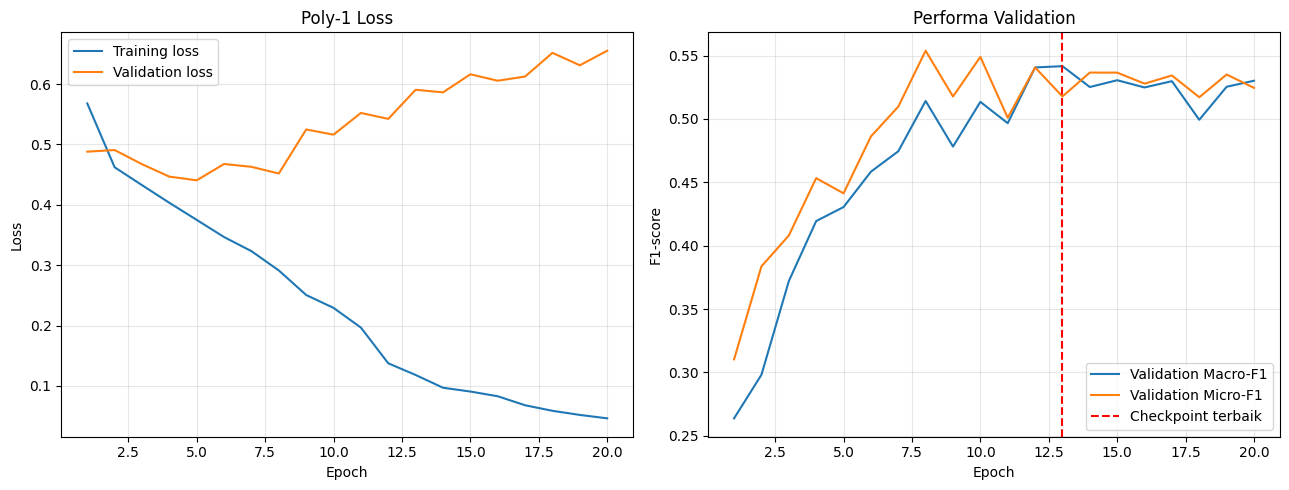

Artefak Poly-1 Loss berhasil disimpan:

- best_polyloss_resnet50.pt: 276328.97 KB
- best_thresholds.json: 0.63 KB
- class_distribution.csv: 0.12 KB
- poly_parameters.json: 0.02 KB
- test_metrics_per_label.csv: 0.88 KB
- test_predictions.csv: 69.95 KB
- test_summary.json: 0.36 KB
- training_curves.png: 169.23 KB
- training_history.json: 4.49 KB


In [5]:
# Menyimpan seluruh artefak Poly-1 Loss

import matplotlib.pyplot as plt


summary_path = (
    POLY_OUTPUT_DIR
    / "test_summary.json"
)

per_label_path = (
    POLY_OUTPUT_DIR
    / "test_metrics_per_label.csv"
)

prediction_path = (
    POLY_OUTPUT_DIR
    / "test_predictions.csv"
)

distribution_path = (
    POLY_OUTPUT_DIR
    / "class_distribution.csv"
)

parameter_path = (
    POLY_OUTPUT_DIR
    / "poly_parameters.json"
)

curve_path = (
    POLY_OUTPUT_DIR
    / "training_curves.png"
)


with open(summary_path, "w") as file:
    json.dump(
        test_summary,
        file,
        indent=2
    )


per_label_table.to_csv(
    per_label_path,
    index=False
)

class_distribution_table.to_csv(
    distribution_path,
    index=False
)

with open(parameter_path, "w") as file:
    json.dump(
        {
            "epsilon": POLY_EPSILON
        },
        file,
        indent=2
    )


prediction_data = {
    "patient_id": test_patient_ids
}

for index, label_name in enumerate(LABELS):
    prediction_data[f"true_{label_name}"] = (
        test_labels[:, index].astype(int)
    )
    prediction_data[f"prob_{label_name}"] = (
        test_probabilities[:, index]
    )
    prediction_data[f"pred_{label_name}"] = (
        test_predictions[:, index].astype(int)
    )


prediction_table = pd.DataFrame(
    prediction_data
)

prediction_table.to_csv(
    prediction_path,
    index=False
)


history_table = pd.DataFrame(
    poly_history
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


axes[0].plot(
    history_table["epoch"],
    history_table["train_loss"],
    label="Training loss"
)

axes[0].plot(
    history_table["epoch"],
    history_table["validation_loss"],
    label="Validation loss"
)

axes[0].set_title("Poly-1 Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    history_table["epoch"],
    history_table["validation_macro_f1"],
    label="Validation Macro-F1"
)

axes[1].plot(
    history_table["epoch"],
    history_table["validation_micro_f1"],
    label="Validation Micro-F1"
)

axes[1].axvline(
    checkpoint["epoch"],
    color="red",
    linestyle="--",
    label="Checkpoint terbaik"
)

axes[1].set_title("Performa Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-score")
axes[1].legend()
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.savefig(
    curve_path,
    dpi=200,
    bbox_inches="tight"
)
plt.show()


print("Artefak Poly-1 Loss berhasil disimpan:\n")

for path in sorted(POLY_OUTPUT_DIR.iterdir()):
    print(
        f"- {path.name}: "
        f"{path.stat().st_size / 1024:.2f} KB"
    )